In [7]:
# Cell 1: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, learning_curve
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print("All libraries imported successfully!")

All libraries imported successfully!


In [8]:
# Cell 2: Load the dataset
df = pd.read_csv('car_price_dataset_cleaned.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)

Dataset shape: (9619, 15)

First 5 rows:


,Brand,Model,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price,Car_Age
0,AUDI,A1,990.0,Automatic,Petrol,99000.0,Gampaha,0,USED,1,1,1,1,100.0,9
1,AUDI,A1,1000.0,Automatic,Petrol,88000.0,Colombo,0,USED,1,1,1,1,97.0,8
2,AUDI,A1,1000.0,Automatic,Petrol,77000.0,Dehiwala-Mount-Lavinia,0,USED,1,1,1,1,98.5,7
3,AUDI,A1,1000.0,Automatic,Petrol,88000.0,Negombo,0,USED,1,1,1,1,107.0,7
4,AUDI,A1,1000.0,Automatic,Petrol,88000.0,Colombo,0,USED,1,1,1,1,99.5,7



Data types:
Brand                 str
Model                 str
Engine (cc)       float64
Gear                  str
Fuel Type             str
Millage(KM)       float64
Town                  str
Leasing               str
Condition             str
AIR CONDITION         str
POWER STEERING        str
POWER MIRROR          str
POWER WINDOW          str
Price             float64
Car_Age             int64
dtype: object


Summary Statistics:


,Brand,Model,Engine (cc),Gear,Fuel Type,Millage(KM),Town,Leasing,Condition,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Price,Car_Age
count,9619,9619,9619.000000,9619,9619,9619.000000,9619,9619,9619,9619,9619,9619,9619,9619.000000,9619.000000
unique,45,1477,NaN,2,4,NaN,107,2,2,2,2,2,2,NaN,NaN
top,TOYOTA,ALTO,NaN,Automatic,Petrol,NaN,Colombo,0,USED,1,1,1,1,NaN,NaN
freq,3081,392,NaN,6167,7752,NaN,983,9217,9531,9425,8775,7147,7867,NaN,NaN
mean,NaN,NaN,1251.588502,NaN,NaN,200367.189937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.382765,17.920886
std,NaN,NaN,394.899881,NaN,NaN,104650.619894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.969991,9.535930
min,NaN,NaN,600.000000,NaN,NaN,11000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.650000,0.000000
25%,NaN,NaN,1000.000000,NaN,NaN,110000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.056000,10.000000
50%,NaN,NaN,1300.000000,NaN,NaN,176000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42.500000,16.000000
75%,NaN,NaN,1500.000000,NaN,NaN,264000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.000000,24.000000



Missing / 'Not_Available' count per column:
Brand                0
Model                0
Engine (cc)          0
Gear                 0
Fuel Type            0
Millage(KM)          0
Town                 0
Leasing              0
Condition            0
AIR CONDITION      194
POWER STEERING     844
POWER MIRROR      2472
POWER WINDOW      1752
Price                0
Car_Age              0
dtype: int64


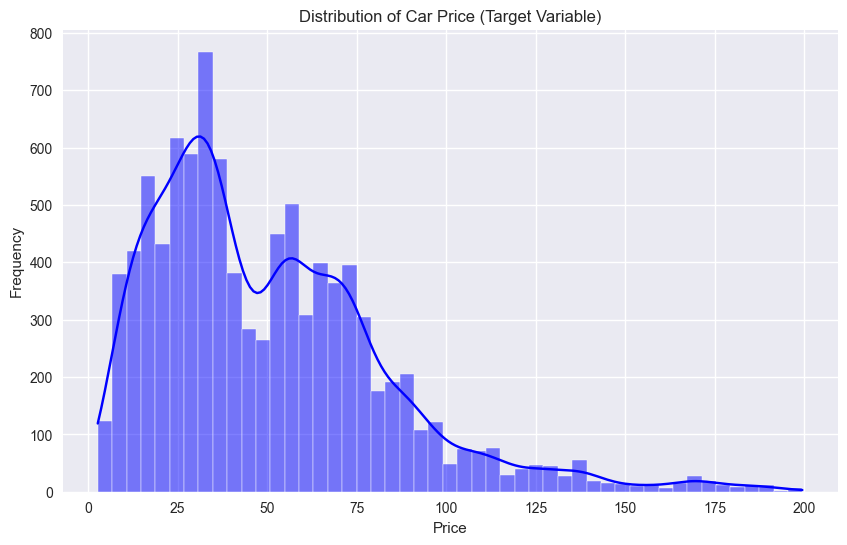

In [9]:
# Cell 3: Basic EDA - Summary statistics and missing values check
print("Summary Statistics:")
display(df.describe(include='all'))

print("\nMissing / 'Not_Available' count per column:")
print((df == 'Not_Available').sum())

# Quick check for target variable
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Car Price (Target Variable)')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [10]:
# Cell 4: Data Cleaning - Handle 'Not_Available', Leasing, and binary features
# Binary features (1 / Not_Available) → convert to 0/1 integers
binary_cols = ['AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']
for col in binary_cols:
    df[col] = df[col].replace('Not_Available', 0)
    df[col] = df[col].replace('1', 1).astype(int)

# Leasing: '0' → 0, 'Ongoing Lease' → 1
df['Leasing'] = df['Leasing'].replace({'0': 0, 'Ongoing Lease': 1}).astype(int)

# Condition remains categorical (NEW / USED)
print("Cleaned binary features sample:")
display(df[binary_cols + ['Leasing', 'Condition']].head())

print("\nNo more 'Not_Available' in binary columns!")
print((df == 'Not_Available').sum())

Cleaned binary features sample:


,AIR CONDITION,POWER STEERING,POWER MIRROR,POWER WINDOW,Leasing,Condition
0,1,1,1,1,0,USED
1,1,1,1,1,0,USED
2,1,1,1,1,0,USED
3,1,1,1,1,0,USED
4,1,1,1,1,0,USED



No more 'Not_Available' in binary columns!
Brand             0
Model             0
Engine (cc)       0
Gear              0
Fuel Type         0
Millage(KM)       0
Town              0
Leasing           0
Condition         0
AIR CONDITION     0
POWER STEERING    0
POWER MIRROR      0
POWER WINDOW      0
Price             0
Car_Age           0
dtype: int64


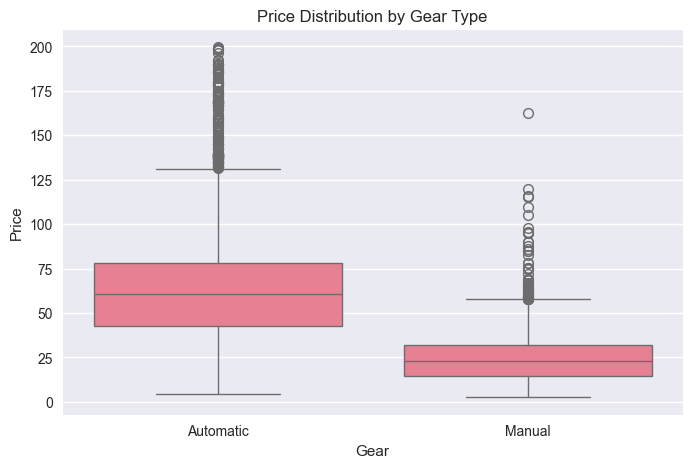

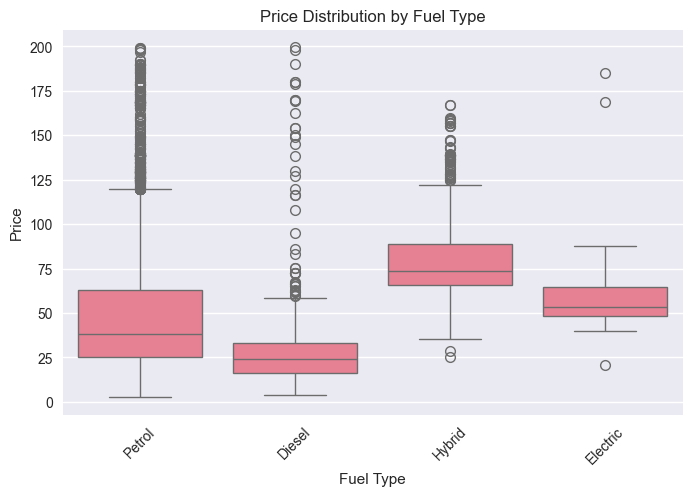

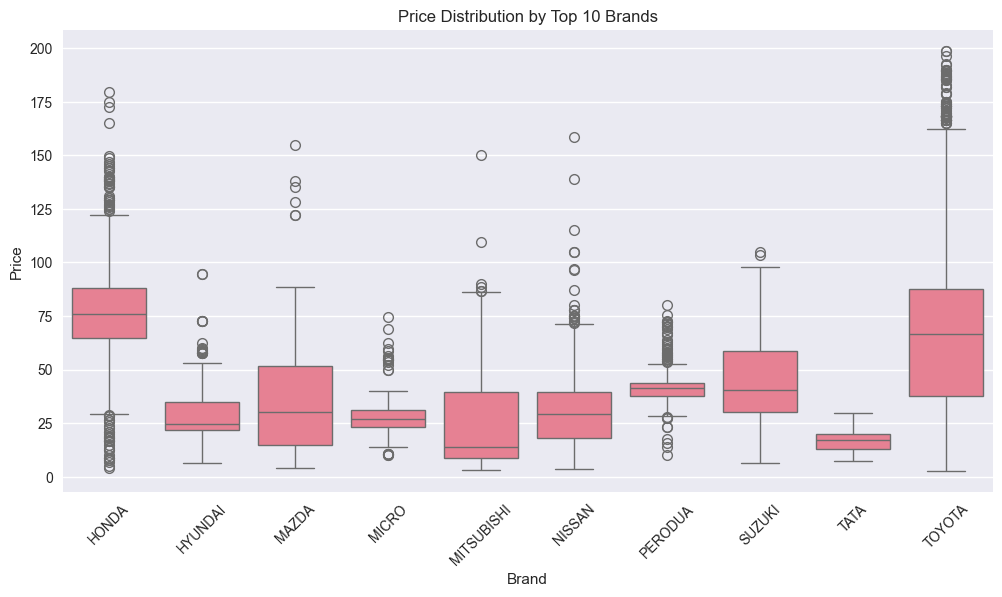

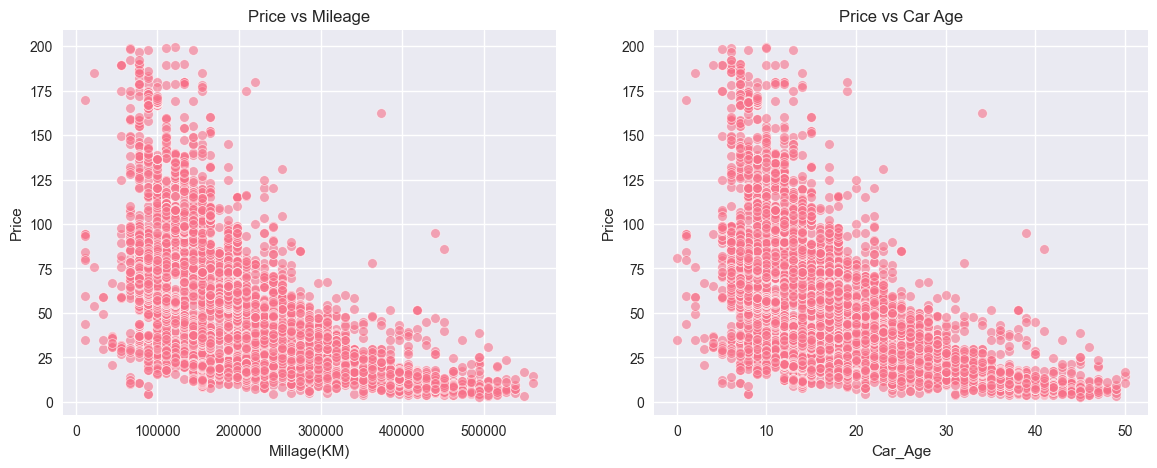

In [11]:
# Cell 5: More EDA Visualizations (Boxplots & Scatter plots)
# Boxplot: Price by Gear
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gear', y='Price', data=df)
plt.title('Price Distribution by Gear Type')
plt.show()

# Boxplot: Price by Fuel Type
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel Type', y='Price', data=df)
plt.title('Price Distribution by Fuel Type')
plt.xticks(rotation=45)
plt.show()

# Top 10 Brands price boxplot
top_brands = df['Brand'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price', data=df[df['Brand'].isin(top_brands)])
plt.title('Price Distribution by Top 10 Brands')
plt.xticks(rotation=45)
plt.show()

# Scatter: Price vs Mileage & Car Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='Millage(KM)', y='Price', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Price vs Mileage')
sns.scatterplot(x='Car_Age', y='Price', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('Price vs Car Age')
plt.show()

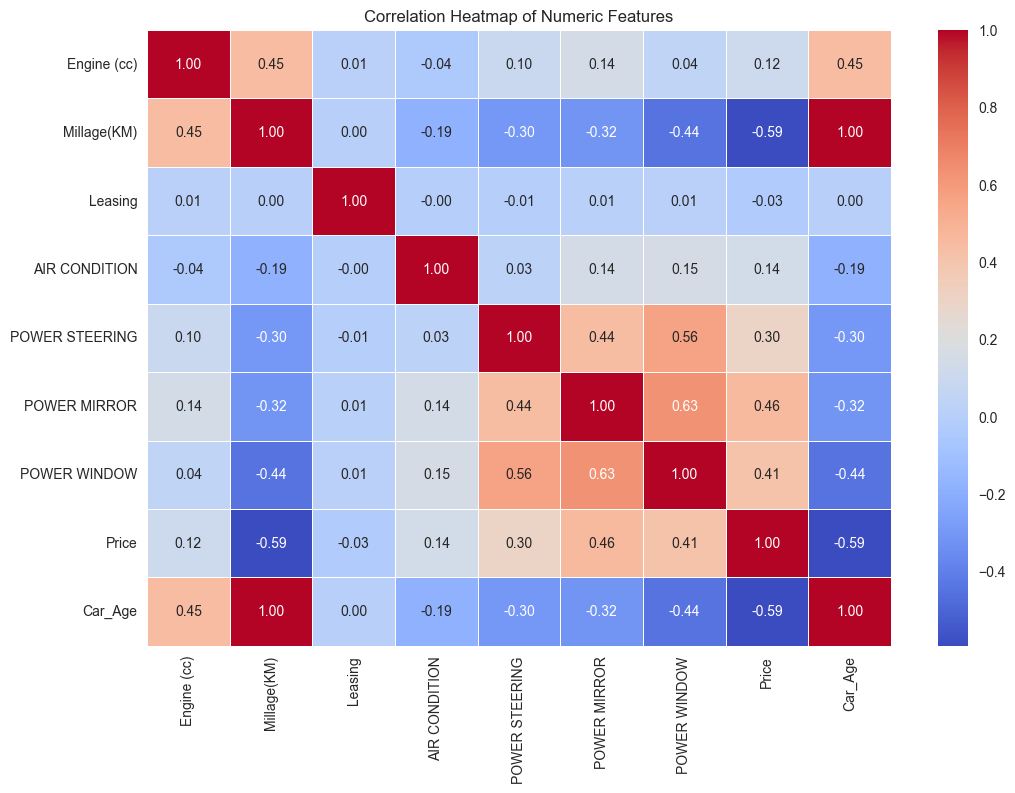

Strongest correlations with Price:
Price             1.000000
POWER MIRROR      0.457821
POWER WINDOW      0.411099
POWER STEERING    0.303167
AIR CONDITION     0.135599
Engine (cc)       0.115585
Leasing          -0.027916
Car_Age          -0.590821
Millage(KM)      -0.592700
Name: Price, dtype: float64


In [12]:
# Cell 6: Correlation Heatmap (Numeric features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

print("Strongest correlations with Price:")
print(corr_matrix['Price'].sort_values(ascending=False))

In [13]:
# Cell 7: Prepare features for modeling
# Define feature lists
num_features = ['Engine (cc)', 'Millage(KM)', 'Car_Age', 'Leasing', 
                'AIR CONDITION', 'POWER STEERING', 'POWER MIRROR', 'POWER WINDOW']
cat_features = ['Brand', 'Model', 'Gear', 'Fuel Type', 'Town', 'Condition']

X = df.drop('Price', axis=1)
y = df['Price']

print(f"Features: {X.shape[1]} columns")
print(f"Numeric: {len(num_features)} | Categorical: {len(cat_features)}")

Features: 14 columns
Numeric: 8 | Categorical: 6


In [14]:
# Cell 8: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 7695 samples
Test set: 1924 samples


In [17]:
# NEW CELL - Insert before your old Cell 9
# Diagnostic: Check cardinality of categorical columns
cat_cols = ['Brand', 'Model', 'Gear', 'Fuel Type', 'Town', 'Condition']
for col in cat_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")

Brand: 45 unique values
Model: 1295 unique values
Gear: 2 unique values
Fuel Type: 4 unique values
Town: 106 unique values
Condition: 2 unique values


In [18]:
# UPDATED CELL 9: Fixed Preprocessor + Model Pipeline (High-Cardinality Fix)
# Separate high-cardinality 'Model' so it is NOT treated as categorical

low_card_cats = ['Brand', 'Gear', 'Fuel Type', 'Town', 'Condition']   # <= 255 categories
high_card     = ['Model']                                             # 1477 categories

preprocessor = ColumnTransformer(
    transformers=[
        ('num',      StandardScaler(), num_features),
        ('high_card', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), high_card),
        ('low_card',  OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), low_card_cats)
    ],
    remainder='drop'
)

# Model (now with safe categorical_features indices)
model = HistGradientBoostingRegressor(
    random_state=42,
    max_bins=255,                    # default is fine now
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    categorical_features=range(len(num_features) + len(high_card), 
                               len(num_features) + len(high_card) + len(low_card_cats))
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', model)
])

print("✅ Fixed pipeline created! (Model is now handled as high-cardinality numeric feature)")

✅ Fixed pipeline created! (Model is now handled as high-cardinality numeric feature)


In [19]:
# Cell 10: Initial Model Training (Baseline) - Run again
pipeline.fit(X_train, y_train)
y_pred_baseline = pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred_baseline)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2   = r2_score(y_test, y_pred_baseline)

print("=== BASELINE MODEL PERFORMANCE ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f} ({r2*100:.2f}%)")

=== BASELINE MODEL PERFORMANCE ===
MAE:  5.21
RMSE: 10.37
R²:   0.9014 (90.14%)


In [20]:
# Cell 11: Fine-Tuning (RandomizedSearchCV) - Now works without error
# (You can increase n_iter=30~50 for even higher accuracy if you have time)

param_dist = {
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'regressor__max_iter': [200, 300, 400],
    'regressor__max_depth': [None, 10, 15, 20],
    'regressor__min_samples_leaf': [1, 5, 10, 20],
    'regressor__l2_regularization': [0, 0.1, 1.0],
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=25,          # ← you can raise this
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

print("\n✅ Best parameters:", random_search.best_params_)
print(f"Best CV R²: {random_search.best_score_:.4f}")

Starting hyperparameter tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Best parameters: {'regressor__min_samples_leaf': 1, 'regressor__max_iter': 400, 'regressor__max_depth': 20, 'regressor__learning_rate': 0.1, 'regressor__l2_regularization': 1.0}
Best CV R²: 0.9191


In [21]:
# Cell 12: Final Tuned Model Evaluation
best_pipeline = random_search.best_estimator_
y_pred = best_pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=== FINAL TUNED MODEL PERFORMANCE ===")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f} ({r2*100:.2f}%)")

=== FINAL TUNED MODEL PERFORMANCE ===
MAE:  5.00
RMSE: 9.72
R²:   0.9134 (91.34%)


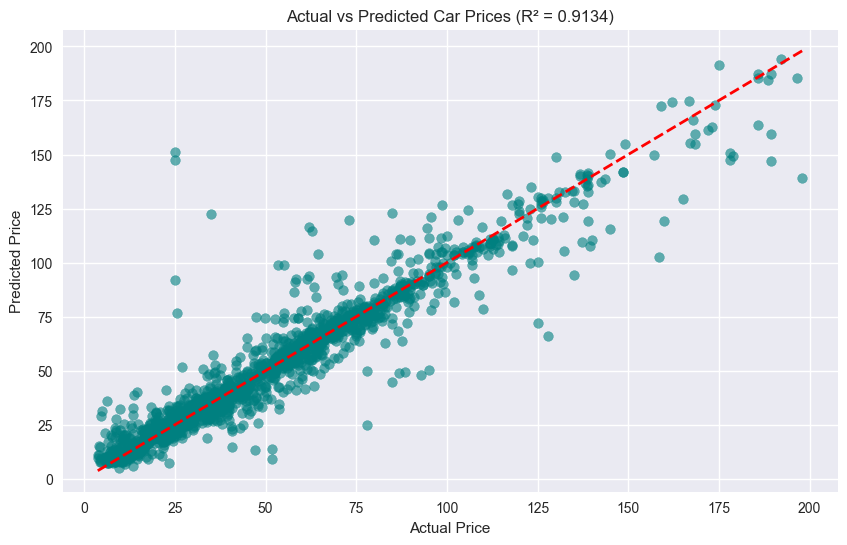

In [22]:
# Cell 13: Visualization 1 - Actual vs Predicted Scatter (Accuracy Plot)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices (R² = {:.4f})'.format(r2))
plt.show()

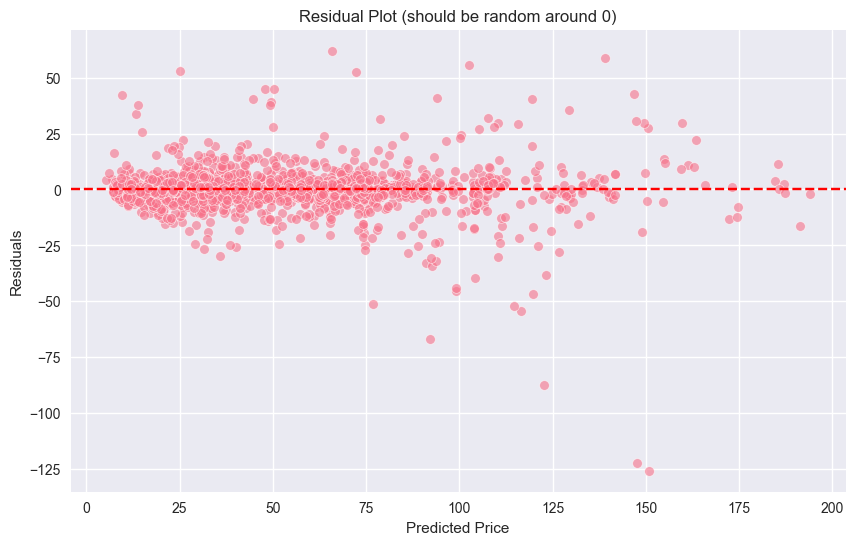

In [23]:
# Cell 14: Visualization 2 - Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot (should be random around 0)')
plt.show()

Calculating permutation importance (this may take 10-20 seconds)...


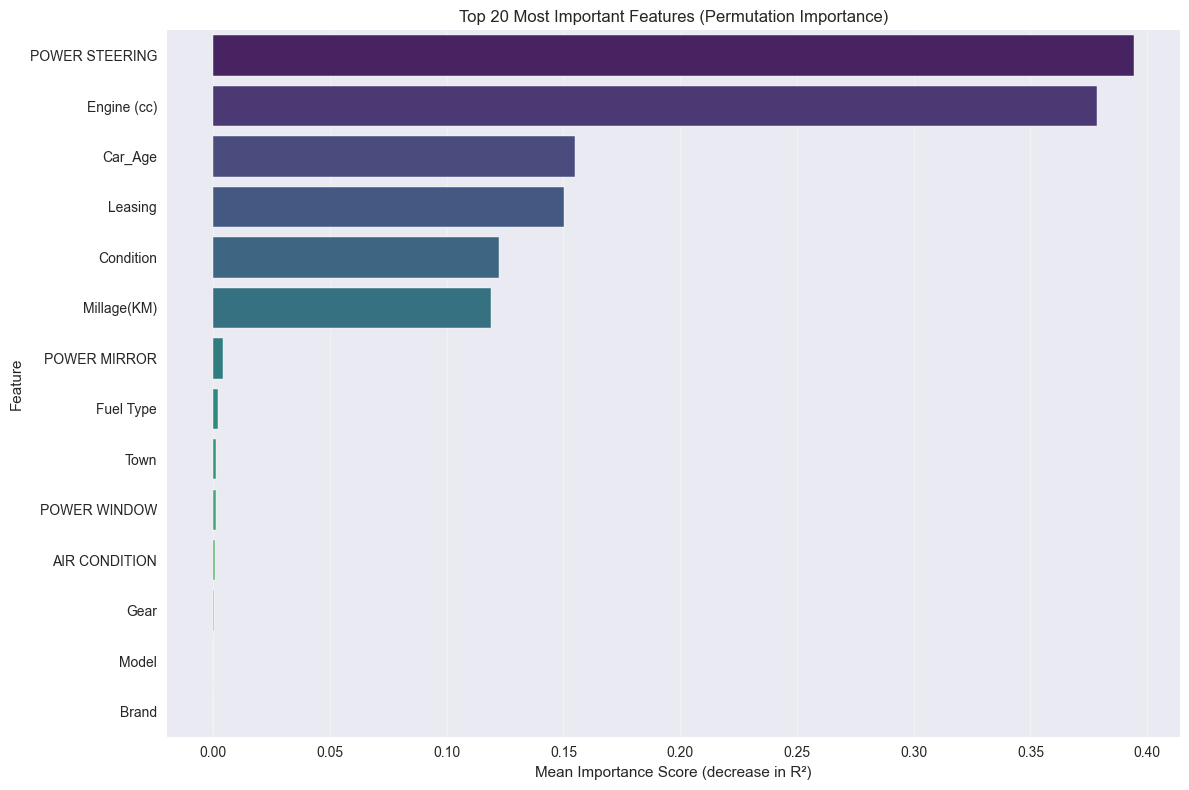


=== Top 10 Feature Importances ===
POWER STEERING    0.3943
Engine (cc)       0.3785
Car_Age           0.1549
Leasing           0.1502
Condition         0.1226
Millage(KM)       0.1192
POWER MIRROR      0.0044
Fuel Type         0.0021
Town              0.0011
POWER WINDOW      0.0011
dtype: float64


In [27]:
# NEW CELL 15: Feature Importance (Top 20) - FIXED with Permutation Importance
from sklearn.inspection import permutation_importance

# 1. Feature names in the exact order after ColumnTransformer
num_feature_names = num_features
high_card_names   = ['Model']
low_card_names    = ['Brand', 'Gear', 'Fuel Type', 'Town', 'Condition']
all_feature_names = num_feature_names + high_card_names + low_card_names

# 2. Calculate permutation importance on TEST set (most reliable)
print("Calculating permutation importance (this may take 10-20 seconds)...")
result = permutation_importance(
    best_pipeline, 
    X_test, 
    y_test,
    n_repeats=10,           # Increase to 20 for more stable results
    random_state=42,
    n_jobs=-1
)

# 3. Create importance DataFrame
feat_imp = pd.Series(result.importances_mean, index=all_feature_names)
feat_imp = feat_imp.sort_values(ascending=False)

# 4. Plot Top 20
plt.figure(figsize=(12, 8))
sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette="viridis")
plt.title('Top 20 Most Important Features (Permutation Importance)')
plt.xlabel('Mean Importance Score (decrease in R²)')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Print top 10 numerically
print("\n=== Top 10 Feature Importances ===")
print(feat_imp.head(10).round(4))

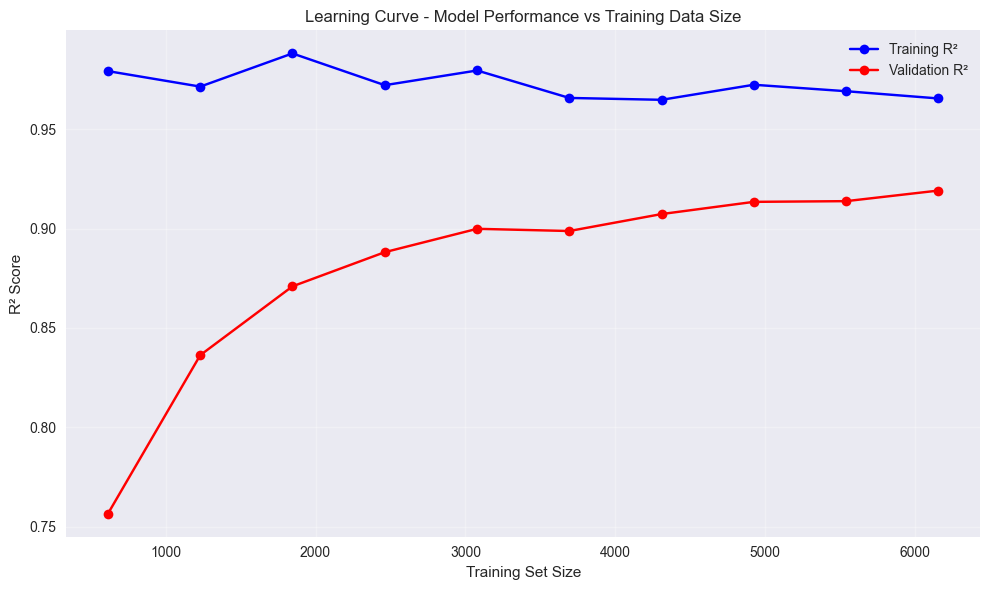

✅ Learning Curve plotted successfully!


In [28]:
# Cell 16: Learning Curve - R² Score vs Training Set Size
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, 
    X_train, 
    y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), 
    cv=5, 
    scoring='r2', 
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training R²', color='blue')
plt.plot(train_sizes, val_mean,   'o-', label='Validation R²', color='red')
plt.title('Learning Curve - Model Performance vs Training Data Size')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Learning Curve plotted successfully!")

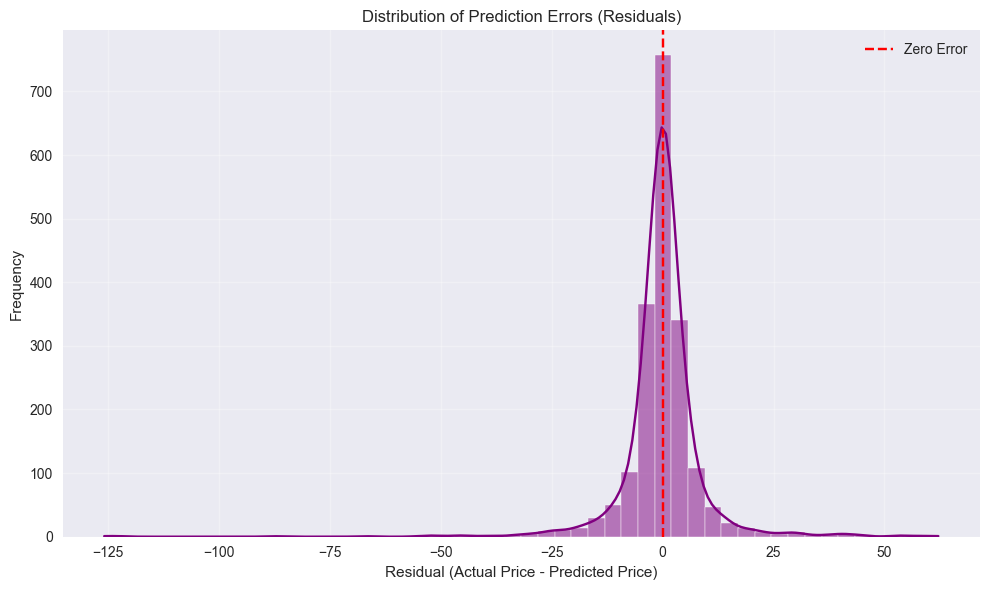

=== Residuals Summary ===
Mean error:     -0.10
Std deviation:  9.72
Max over-prediction:  62.13
Max under-prediction: -125.93


In [29]:
# Cell 17: Distribution of Prediction Errors (Residuals)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Residual (Actual Price - Predicted Price)')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics of errors
print("=== Residuals Summary ===")
print(f"Mean error:     {residuals.mean():.2f}")
print(f"Std deviation:  {residuals.std():.2f}")
print(f"Max over-prediction:  {residuals.max():.2f}")
print(f"Max under-prediction: {residuals.min():.2f}")

In [30]:
# Cell 18: Export the final tuned model
import joblib

# Save the complete pipeline (preprocessor + best model)
joblib.dump(best_pipeline, 'tuned_car_price_model.pkl')

print("🎉 Model successfully exported!")
print("📁 File saved as: tuned_car_price_model.pkl")
print("\nYou can now use this file in any other notebook or Python script.")

🎉 Model successfully exported!
📁 File saved as: tuned_car_price_model.pkl

You can now use this file in any other notebook or Python script.


In [31]:
# Cell 19: Load the model and make predictions on new cars

import joblib
import pandas as pd

# Load the saved model
loaded_model = joblib.load('tuned_car_price_model.pkl')
print("✅ Model loaded successfully!")

# Example: Predict price for a new car
new_car = pd.DataFrame([{
    'Brand': 'TOYOTA',
    'Model': 'VITZ',
    'Engine (cc)': 1000.0,
    'Gear': 'Automatic',
    'Fuel Type': 'Petrol',
    'Millage(KM)': 77000.0,
    'Town': 'Colombo',
    'Leasing': 0,
    'Condition': 'USED',
    'AIR CONDITION': 1,
    'POWER STEERING': 1,
    'POWER MIRROR': 1,
    'POWER WINDOW': 1,
    'Car_Age': 7
}])

predicted_price = loaded_model.predict(new_car)[0]
print(f"\nPredicted Price for this car: {predicted_price:.2f} (in your dataset units)")

✅ Model loaded successfully!

Predicted Price for this car: 91.40 (in your dataset units)


📁 Export folder created: car_price_exports/
✅ Model saved as: tuned_car_price_model.pkl
✅ Feature importance saved as: feature_importance.csv
✅ Test predictions saved as: test_predictions.csv

🎉 ALL FILES EXPORTED SUCCESSFULLY!
📂 Check the folder: car_price_exports/
Files saved:
   • tuned_car_price_model.pkl
   • feature_importance.csv
   • test_predictions.csv
   • 11 high-quality PNG graphs (01 to 11)


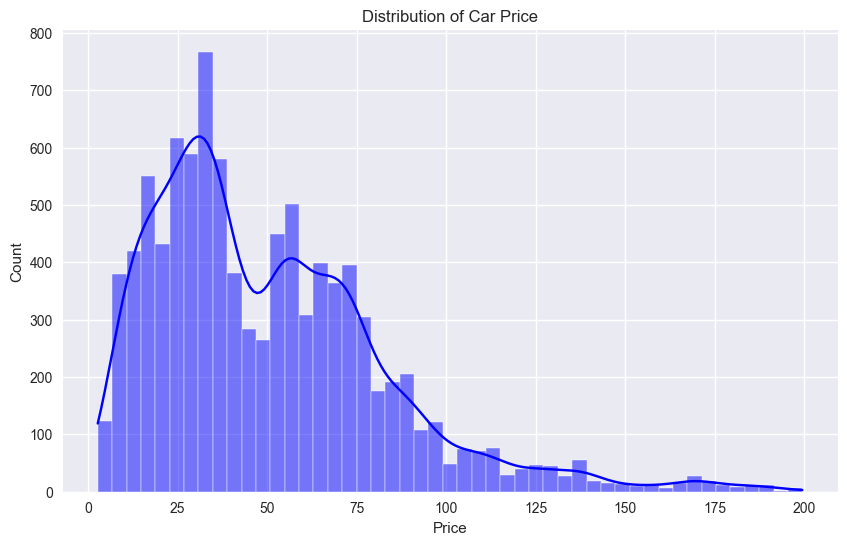

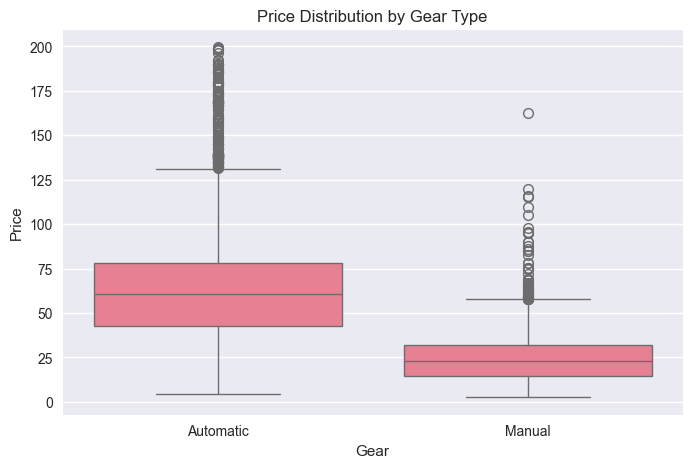

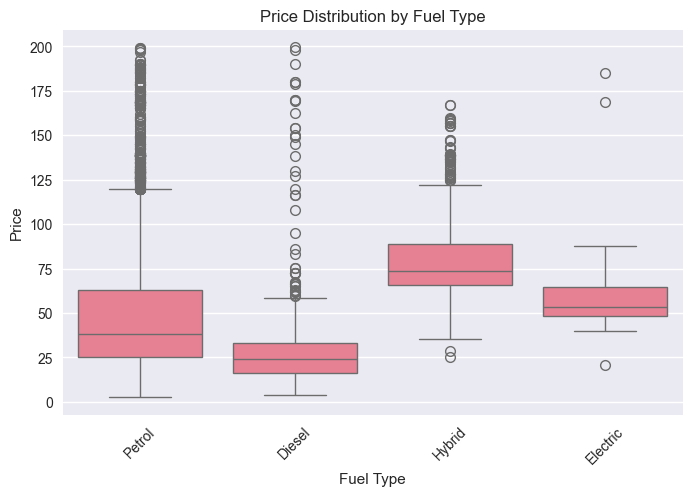

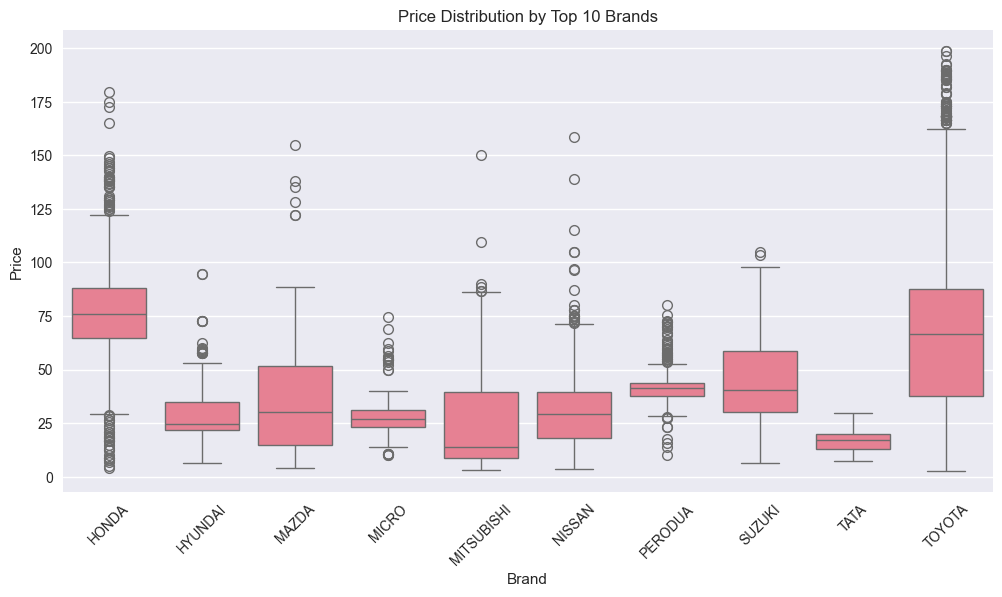

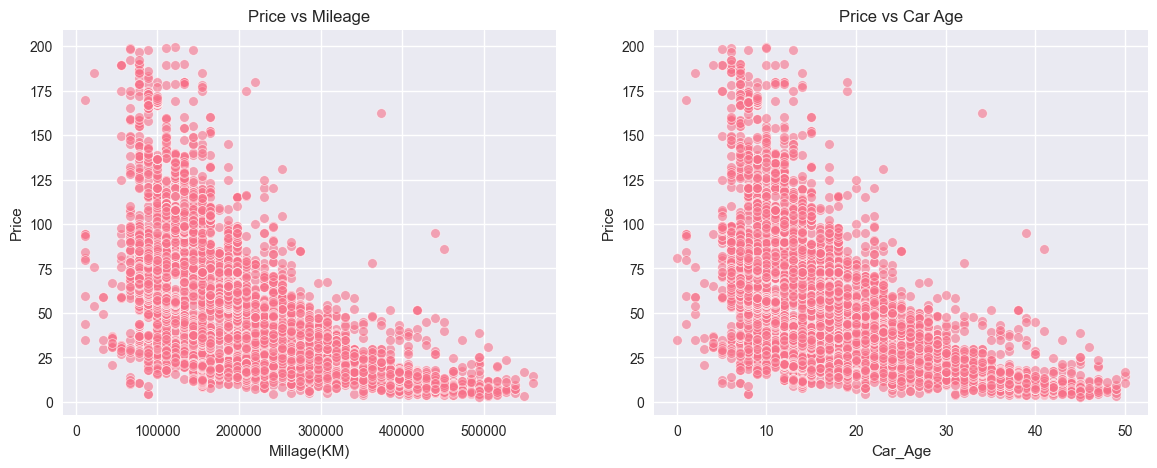

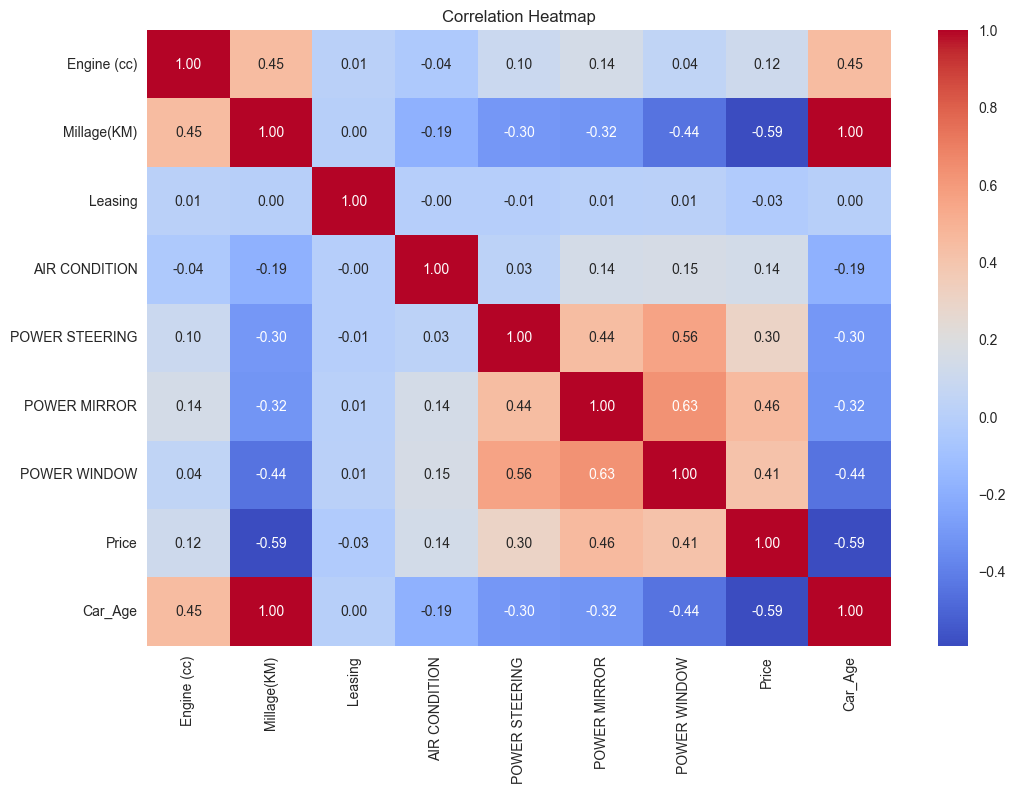

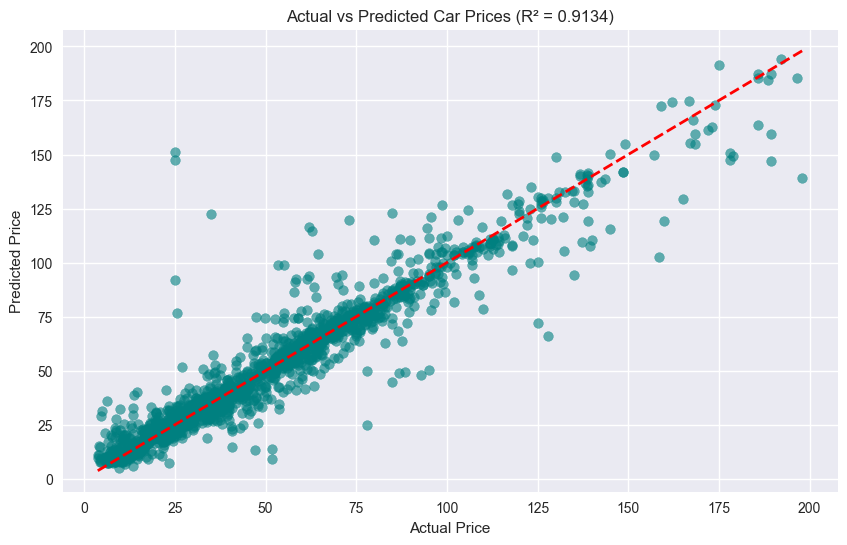

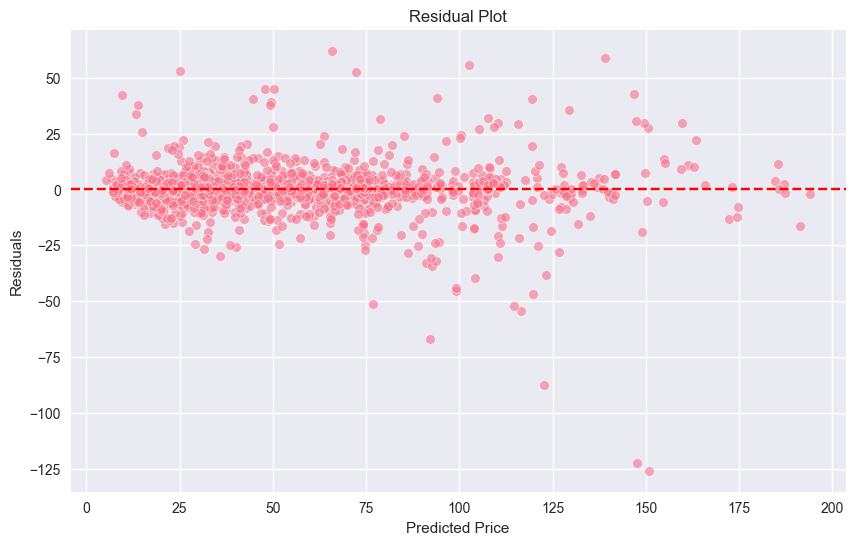

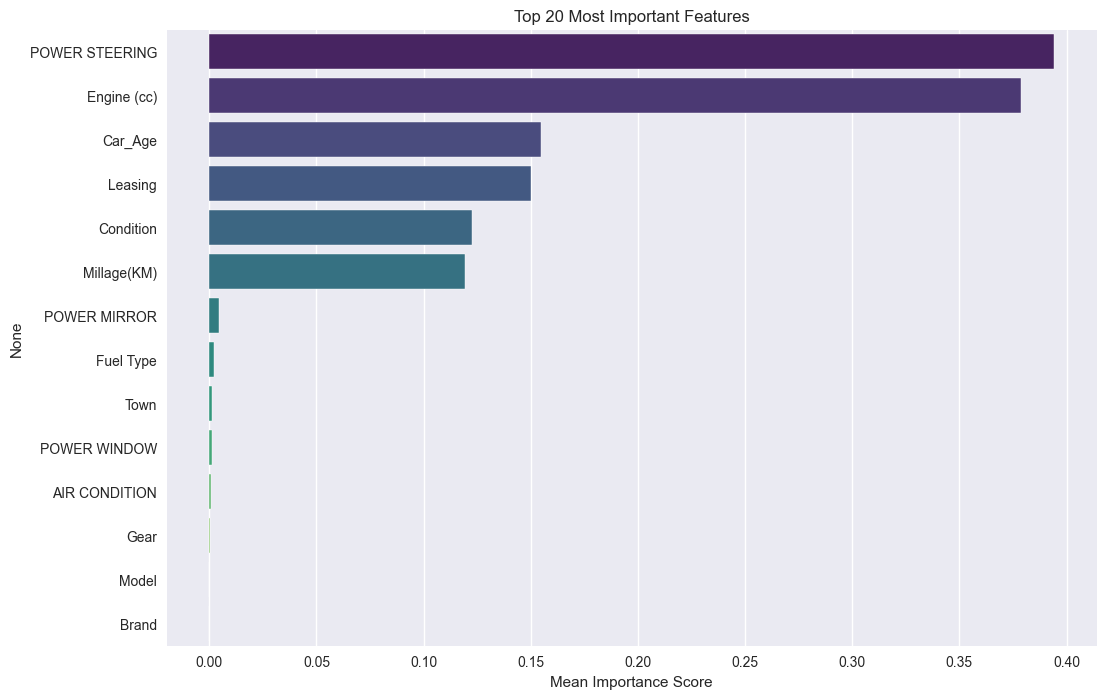

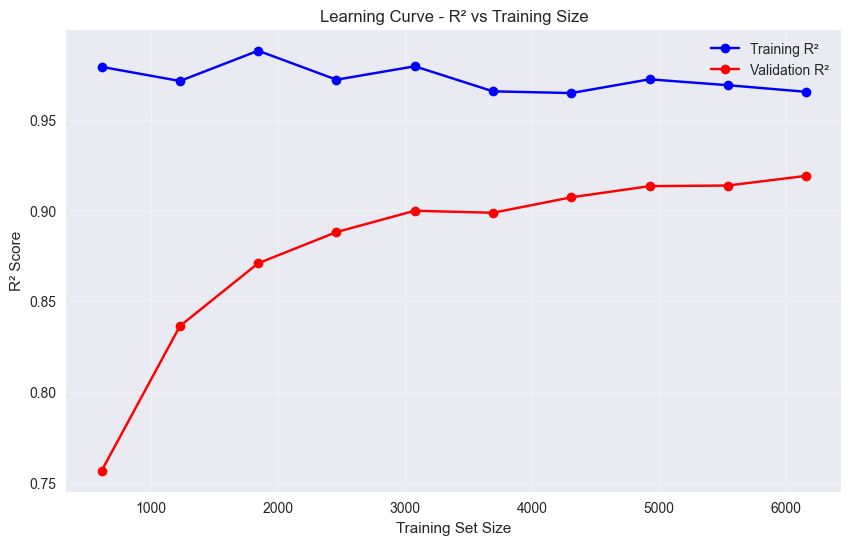

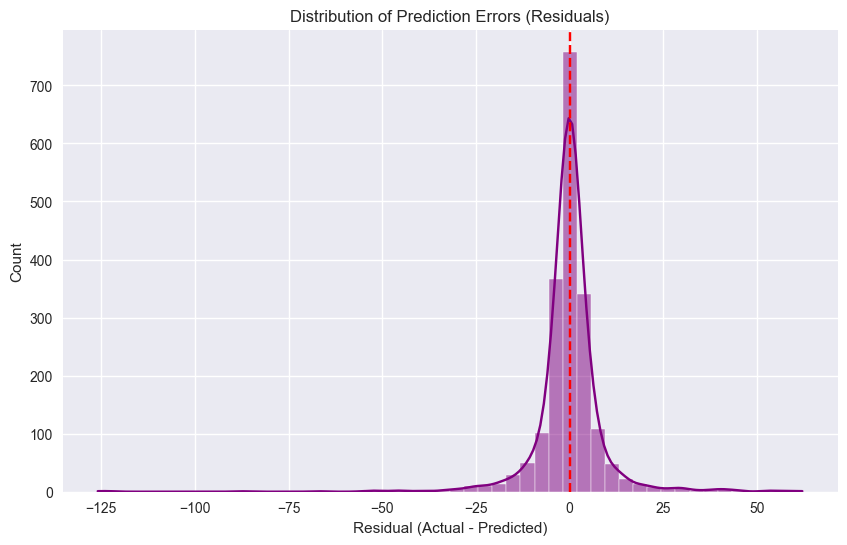

In [32]:
# =============================================================================
# FINAL CELL: EXPORT ALL GRAPHS + MODEL + FILES
# =============================================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

# Create export folder
export_folder = 'car_price_exports'
os.makedirs(export_folder, exist_ok=True)
print(f"📁 Export folder created: {export_folder}/")

# ====================== 1. SAVE THE MODEL ======================
import joblib
joblib.dump(best_pipeline, f'{export_folder}/tuned_car_price_model.pkl')
print("✅ Model saved as: tuned_car_price_model.pkl")

# ====================== 2. SAVE FEATURE IMPORTANCE ======================
# Re-calculate permutation importance (same as Cell 15)
result = permutation_importance(best_pipeline, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
num_feature_names = num_features
high_card_names   = ['Model']
low_card_names    = ['Brand', 'Gear', 'Fuel Type', 'Town', 'Condition']
all_feature_names = num_feature_names + high_card_names + low_card_names

feat_imp = pd.Series(result.importances_mean, index=all_feature_names).sort_values(ascending=False)
feat_imp.to_csv(f'{export_folder}/feature_importance.csv')
print("✅ Feature importance saved as: feature_importance.csv")

# ====================== 3. SAVE TEST PREDICTIONS ======================
predictions_df = pd.DataFrame({
    'Actual_Price': y_test,
    'Predicted_Price': y_pred,
    'Residual': y_test - y_pred
}).reset_index(drop=True)
predictions_df.to_csv(f'{export_folder}/test_predictions.csv', index=False)
print("✅ Test predictions saved as: test_predictions.csv")

# ====================== 4. SAVE ALL GRAPHS ======================

# Graph 1: Price Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], kde=True, color='blue')
plt.title('Distribution of Car Price')
plt.savefig(f'{export_folder}/01_price_distribution.png', dpi=300, bbox_inches='tight')

# Graph 2: Price by Gear
plt.figure(figsize=(8, 5))
sns.boxplot(x='Gear', y='Price', data=df)
plt.title('Price Distribution by Gear Type')
plt.savefig(f'{export_folder}/02_price_by_gear.png', dpi=300, bbox_inches='tight')

# Graph 3: Price by Fuel Type
plt.figure(figsize=(8, 5))
sns.boxplot(x='Fuel Type', y='Price', data=df)
plt.title('Price Distribution by Fuel Type')
plt.xticks(rotation=45)
plt.savefig(f'{export_folder}/03_price_by_fuel.png', dpi=300, bbox_inches='tight')

# Graph 4: Price by Top 10 Brands
top_brands = df['Brand'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(x='Brand', y='Price', data=df[df['Brand'].isin(top_brands)])
plt.title('Price Distribution by Top 10 Brands')
plt.xticks(rotation=45)
plt.savefig(f'{export_folder}/04_price_by_top_brands.png', dpi=300, bbox_inches='tight')

# Graph 5 & 6: Price vs Mileage & Car Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x='Millage(KM)', y='Price', data=df, ax=axes[0], alpha=0.6)
axes[0].set_title('Price vs Mileage')
sns.scatterplot(x='Car_Age', y='Price', data=df, ax=axes[1], alpha=0.6)
axes[1].set_title('Price vs Car Age')
plt.savefig(f'{export_folder}/05_scatter_mileage_age.png', dpi=300, bbox_inches='tight')

# Graph 7: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig(f'{export_folder}/06_correlation_heatmap.png', dpi=300, bbox_inches='tight')

# Graph 8: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted Car Prices (R² = {r2:.4f})')
plt.savefig(f'{export_folder}/07_actual_vs_predicted.png', dpi=300, bbox_inches='tight')

# Graph 9: Residual Plot
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.savefig(f'{export_folder}/08_residual_plot.png', dpi=300, bbox_inches='tight')

# Graph 10: Feature Importance (Top 20)
plt.figure(figsize=(12, 8))
sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette="viridis")
plt.title('Top 20 Most Important Features')
plt.xlabel('Mean Importance Score')
plt.savefig(f'{export_folder}/09_feature_importance.png', dpi=300, bbox_inches='tight')

# Graph 11: Learning Curve
from sklearn.model_selection import learning_curve
train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='r2', n_jobs=-1, random_state=42
)
train_mean = np.mean(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training R²', color='blue')
plt.plot(train_sizes, val_mean,   'o-', label='Validation R²', color='red')
plt.title('Learning Curve - R² vs Training Size')
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{export_folder}/10_learning_curve.png', dpi=300, bbox_inches='tight')

# Graph 12: Residuals Distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='purple', bins=50)
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Residual (Actual - Predicted)')
plt.axvline(x=0, color='red', linestyle='--')
plt.savefig(f'{export_folder}/11_residuals_distribution.png', dpi=300, bbox_inches='tight')

print("\n🎉 ALL FILES EXPORTED SUCCESSFULLY!")
print(f"📂 Check the folder: {export_folder}/")
print("Files saved:")
print("   • tuned_car_price_model.pkl")
print("   • feature_importance.csv")
print("   • test_predictions.csv")
print("   • 11 high-quality PNG graphs (01 to 11)")

In [35]:
# Cell: Generate comparison table for your final model

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Get train predictions
y_train_pred = best_pipeline.predict(X_train)

# Compute metrics
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

# MAPE: mean absolute percentage error (as decimal, e.g., 0.131 = 13.1%)
test_mape = np.mean(np.abs((y_test - y_pred) / y_test))

# RMSE Gap (test - train)
rmse_gap = test_rmse - train_rmse

# Number of original features (before any encoding)
num_features_original = X.shape[1]

# Create the table
results = pd.DataFrame({
    'Model': ['HistGradientBoostingRegressor (Tuned)'],
    'Type': ['Gradient Boosting Regressor'],
    'Features': [num_features_original],
    'Train RMSE': [train_rmse],
    'Test RMSE': [test_rmse],
    'Test MAE': [test_mae],
    'Test R2': [test_r2],
    'Test MAPE': [test_mape],
    'RMSE Gap': [rmse_gap]
})

# Format to match your table style (2-4 decimals)
results = results.round({
    'Train RMSE': 3,
    'Test RMSE': 3,
    'Test MAE': 3,
    'Test R2': 4,
    'Test MAPE': 4,
    'RMSE Gap': 3
})

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*70)
display(results)
print("\n(All values are on the same scale as your price target.)")


FINAL MODEL PERFORMANCE SUMMARY


,Model,Type,Features,Train RMSE,Test RMSE,Test MAE,Test R2,Test MAPE,RMSE Gap
0,HistGradientBoostingRegressor (Tuned),Gradient Boosting Regressor,14,4.882,9.719,4.996,0.9134,0.1471,4.837



(All values are on the same scale as your price target.)


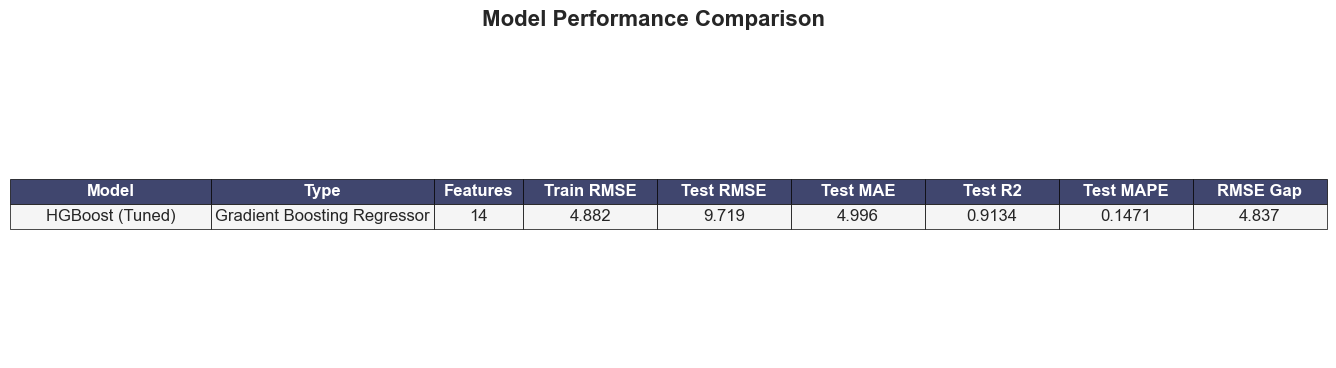

✅ Table saved as 'car_price_exports/model_performance_table.png'


In [38]:
# Cell: Export the performance table as a high-quality image (shortened model name)

import matplotlib.pyplot as plt

# Prepare the data: convert DataFrame to a list of lists (including header)
data = [results.columns.tolist()] + results.values.tolist()

# Shorten the model name in the first data row (index 1)
data[1][0] = 'HGBoost (Tuned)'   # change to any short name you like

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 4))  # adjust width/height as needed
ax.axis('off')  # hide axes

# Create the table
table = ax.table(
    cellText=data,
    loc='center',
    cellLoc='center',          # center-align text in cells
    colWidths=[0.18, 0.2, 0.08, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12]  # manually set widths (adjust as needed)
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)  # scale (x, y) for better spacing

# Color the header row
for (i, j), cell in table.get_celld().items():
    if i == 0:  # header row
        cell.set_facecolor('#40466e')
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#f5f5f5')
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)

# Add a title
plt.suptitle('Model Performance Comparison', fontsize=16, weight='bold', y=0.98)

# Save the image
plt.savefig('car_price_exports/model_performance_table.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Table saved as 'car_price_exports/model_performance_table.png'")

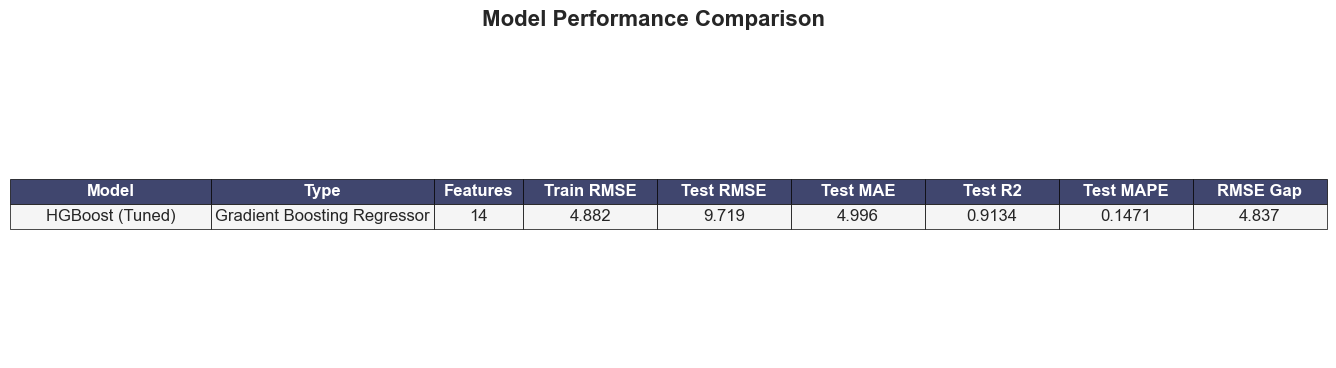

✅ Table image saved as 'car_price_exports/model_performance_table.png'


In [39]:
# Cell: Export the performance table as a high-quality image (shortened model name)
import matplotlib.pyplot as plt
import os

# Ensure export folder exists
os.makedirs('car_price_exports', exist_ok=True)

# Prepare the data: convert DataFrame to a list of lists (including header)
data = [results.columns.tolist()] + results.values.tolist()

# Shorten the model name in the first data row (index 1)
data[1][0] = 'HGBoost (Tuned)'   # change to any short name you like

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('off')

# Create the table
table = ax.table(
    cellText=data,
    loc='center',
    cellLoc='center',
    colWidths=[0.18, 0.2, 0.08, 0.12, 0.12, 0.12, 0.12, 0.12, 0.12]
)

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)

# Color the header row
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_facecolor('#40466e')
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#f5f5f5')
    cell.set_edgecolor('black')
    cell.set_linewidth(0.5)

# Add a title
plt.suptitle('Model Performance Comparison', fontsize=16, weight='bold', y=0.98)

# Save and display
plt.savefig('car_price_exports/model_performance_table.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Table image saved as 'car_price_exports/model_performance_table.png'")

Over-predicted (> 5% high): 548
Under-predicted (< 5% low): 512
Correct (within ±5%): 864
Total: 1924


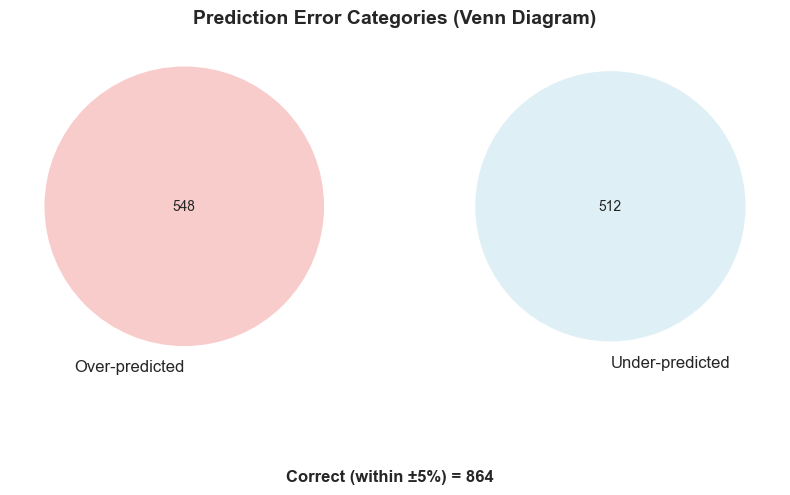

✅ Venn diagram saved as 'car_price_exports/venn_diagram_error_categories.png'


<Figure size 800x550 with 0 Axes>

In [41]:
# Cell: Venn diagram of prediction error categories
# (Run this cell after your model evaluation)
# Install if needed: !pip install matplotlib-venn

import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import numpy as np

# Define tolerance (5%)
tolerance = 0.05

# Compute counts
over_pred  = np.sum(y_pred > y_test * (1 + tolerance))
under_pred = np.sum(y_pred < y_test * (1 - tolerance))
correct    = np.sum((y_pred >= y_test * (1 - tolerance)) & (y_pred <= y_test * (1 + tolerance)))

print(f"Over-predicted (> {tolerance*100:.0f}% high): {over_pred}")
print(f"Under-predicted (< {tolerance*100:.0f}% low): {under_pred}")
print(f"Correct (within ±{tolerance*100:.0f}%): {correct}")
print(f"Total: {over_pred + under_pred + correct}")

# Create Venn diagram
plt.figure(figsize=(8, 6))
venn = venn2(subsets=(over_pred, under_pred, 0), set_labels=('Over-predicted', 'Under-predicted'))

# Colour the circles
venn.get_patch_by_id('10').set_facecolor('lightcoral')
venn.get_patch_by_id('01').set_facecolor('lightblue')

# Set text for the two circles (they always exist)
venn.get_label_by_id('10').set_text(over_pred)
venn.get_label_by_id('01').set_text(under_pred)

# Intersection label might be None if no overlap → safely ignore
overlap_label = venn.get_label_by_id('11')
if overlap_label is not None:
    overlap_label.set_text('')   # hide it

# Add a text annotation for the "correct" predictions (outside both circles)
plt.text(0.0, -0.8, f"Correct (within ±{tolerance*100:.0f}%) = {correct}", 
         ha='center', fontsize=12, weight='bold')

plt.title('Prediction Error Categories (Venn Diagram)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# Save the figure
plt.savefig('car_price_exports/venn_diagram_error_categories.png', dpi=300, bbox_inches='tight')
print("✅ Venn diagram saved as 'car_price_exports/venn_diagram_error_categories.png'")

Over-predicted: 548
Under-predicted: 512
Correct: 864


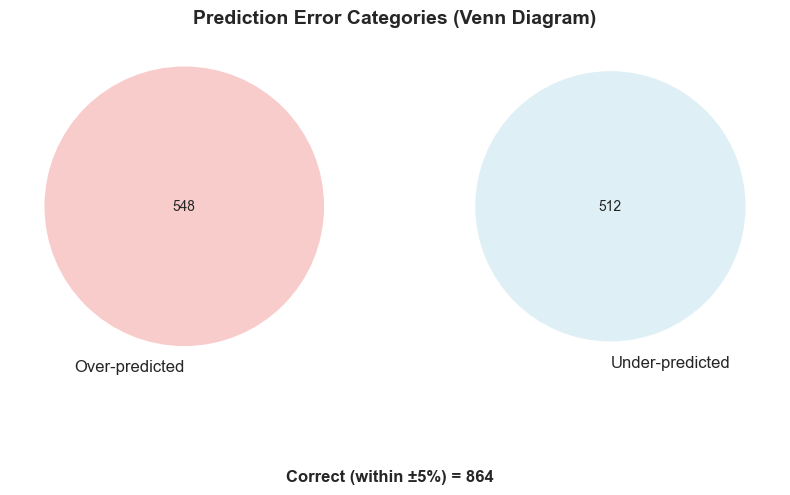

✅ Venn diagram saved as 'car_price_exports/venn_diagram_error_categories.png'


In [42]:
# Cell: Venn diagram of prediction error categories
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import numpy as np
import os

# Ensure export folder exists
os.makedirs('car_price_exports', exist_ok=True)

# Define tolerance (5%)
tolerance = 0.05

# Compute counts
over_pred  = np.sum(y_pred > y_test * (1 + tolerance))
under_pred = np.sum(y_pred < y_test * (1 - tolerance))
correct    = np.sum((y_pred >= y_test * (1 - tolerance)) & (y_pred <= y_test * (1 + tolerance)))

print(f"Over-predicted: {over_pred}")
print(f"Under-predicted: {under_pred}")
print(f"Correct: {correct}")

# Create Venn diagram
plt.figure(figsize=(8, 6))
venn = venn2(subsets=(over_pred, under_pred, 0), set_labels=('Over-predicted', 'Under-predicted'))

# Colour the circles
venn.get_patch_by_id('10').set_facecolor('lightcoral')
venn.get_patch_by_id('01').set_facecolor('lightblue')

# Set text for the two circles
venn.get_label_by_id('10').set_text(over_pred)
venn.get_label_by_id('01').set_text(under_pred)

# Intersection label might be None if no overlap → safely ignore
overlap_label = venn.get_label_by_id('11')
if overlap_label is not None:
    overlap_label.set_text('')

# Add a text annotation for the "correct" predictions
plt.text(0.0, -0.8, f"Correct (within ±{tolerance*100:.0f}%) = {correct}", 
         ha='center', fontsize=12, weight='bold')

plt.title('Prediction Error Categories (Venn Diagram)', fontsize=14, weight='bold')
plt.tight_layout()

# Save the image
plt.savefig('car_price_exports/venn_diagram_error_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Venn diagram saved as 'car_price_exports/venn_diagram_error_categories.png'")